# LLM Call Failure Statistics Analysis

This notebook analyzes the failure statistics from llm_calls.txt files in the LASR runs.

## Log Format
The llm_calls.txt files contain operation logs in the following format:
- Success: `[operation] content`  (e.g., `[mutate] (sin(x) + cos(y))`)
- Failure: `[operation|failed] content`  (e.g., `[mutate|failed] None`)

Where operation can be: `ideas`, `gen_random`, `mutate`, or `crossover`

## Pairing Logic
When two consecutive operations of the same type appear, they are grouped as a pair.
If either operation in the pair fails, the entire pair is marked as failed.

In [39]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

# Define experiment labels - extended to include all experiments
exp_labels = {
    0: 'Llama3.2',
    1: 'Llama3.2 p',
    2: 'Llama3.2 ph',
    3: 'Llama3.2 phw',
    4: 'Qwen3-8B',
    5: 'Qwen3-8B-think',
    6: 'DeepSeek V3',
    7: 'DeepSeek R1',
    8: 'Exp_8',  # Dynamic label for missing experiment
    9: 'Qwen3-8B w*',
    10: 'Llama3.2 p*',
    11: 'Qwen3-8B p*',
    12: 'Qwen3-8B-think p*',
    13: 'DeepSeek V3 p*',
    14: 'DeepSeek R1 p*'
}

# Function to auto-detect available experiments
def detect_available_experiments(base_path):
    """Auto-detect all available exp_N directories and check if they have data."""
    base_path = Path(base_path)
    available_experiments = []
    
    # Find all exp_N directories
    exp_dirs = [d for d in base_path.iterdir() if d.is_dir() and d.name.startswith('exp_')]
    
    for exp_dir in sorted(exp_dirs):
        try:
            exp_num = int(exp_dir.name.replace('exp_', ''))
            
            # Check if this experiment has actual data (equation directories)
            eq_dirs = [d for d in exp_dir.iterdir() if d.is_dir() and d.name.isdigit()]
            
            if eq_dirs:
                # Check if at least one equation directory has llm_calls.txt
                has_data = False
                for eq_dir in eq_dirs:
                    if (eq_dir / "llm_calls.txt").exists():
                        has_data = True
                        break
                
                if has_data:
                    available_experiments.append(exp_num)
                    print(f"✓ Found experiment {exp_num} with data ({len(eq_dirs)} equations)")
                else:
                    print(f"! Found experiment {exp_num} but no llm_calls.txt files")
            else:
                print(f"! Found experiment {exp_num} but no equation directories")
                
        except ValueError:
            print(f"! Skipping non-numeric experiment directory: {exp_dir.name}")
    
    return sorted(available_experiments)

print("Experiment Detection:")
print("="*50)

Experiment Detection:


In [40]:
def count_patterns_in_file(file_path):
    """Count [ideas], [gen_random], [mutate], [crossover] patterns and their failures in a file.
    
    Based on the actual logging format:
    - Success: [operation] content
    - Failure: [operation|failed] content
    
    Pairing logic:
    - mutate/crossover: Group consecutive operations as pairs (retry mechanism)
    - ideas/gen_random: Usually single operations, but still check for pairs
    
    If any operation in a pair fails, mark the entire pair as failed.
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        
        import re
        
        # Find all operation lines with their type and status
        operations = []
        
        for i, line in enumerate(lines):
            line = line.strip()
            
            # Pattern for successful operations: [operation] content
            success_match = re.match(r'^\[(ideas|gen_random|mutate|crossover)\]\s*(.*)$', line)
            if success_match:
                operations.append({
                    'type': success_match.group(1),
                    'failed': False,
                    'content': success_match.group(2),
                    'line_num': i
                })
                continue
            
            # Pattern for failed operations: [operation|failed] content
            failed_match = re.match(r'^\[(ideas|gen_random|mutate|crossover)\|failed\]\s*(.*)$', line)
            if failed_match:
                operations.append({
                    'type': failed_match.group(1),
                    'failed': True,
                    'content': failed_match.group(2),
                    'line_num': i
                })
        
        # Group consecutive operations of the same type
        grouped_operations = []
        i = 0
        
        while i < len(operations):
            current = operations[i]
            
            # Check if there's a next operation of the same type that's consecutive
            # For mutate/crossover: more likely to have pairs (retry mechanism)
            # For ideas/gen_random: less likely, but still check
            max_line_gap = 20 if current['type'] in ['mutate', 'crossover'] else 10
            
            if (i + 1 < len(operations) and 
                operations[i + 1]['type'] == current['type'] and
                operations[i + 1]['line_num'] - current['line_num'] < max_line_gap):
                
                # This is a pair of consecutive operations
                next_op = operations[i + 1]
                
                # If either operation failed, the pair failed
                pair_failed = current['failed'] or next_op['failed']
                
                grouped_operations.append({
                    'type': current['type'],
                    'failed': pair_failed,
                    'is_pair': True,
                    'count': 2,  # This represents 2 operations grouped as 1 unit
                    'details': f"Pair: {'FAIL' if current['failed'] else 'OK'} + {'FAIL' if next_op['failed'] else 'OK'} = {'FAIL' if pair_failed else 'OK'}"
                })
                
                i += 2  # Skip both operations as they're now grouped
            else:
                # Single operation (not part of a consecutive pair)
                grouped_operations.append({
                    'type': current['type'],
                    'failed': current['failed'],
                    'is_pair': False,
                    'count': 1,  # Single operation
                    'details': f"Single: {'FAIL' if current['failed'] else 'OK'}"
                })
                
                i += 1
        
        # Count the results
        counts = {
            'ideas_success': 0,
            'ideas_failed': 0,
            'gen_random_success': 0,
            'gen_random_failed': 0,
            'mutate_success': 0,
            'mutate_failed': 0,
            'crossover_success': 0,
            'crossover_failed': 0
        }
        
        # Also track detailed statistics
        operation_details = {
            'ideas': {'single': 0, 'pairs': 0, 'total_ops': 0},
            'gen_random': {'single': 0, 'pairs': 0, 'total_ops': 0},
            'mutate': {'single': 0, 'pairs': 0, 'total_ops': 0},
            'crossover': {'single': 0, 'pairs': 0, 'total_ops': 0}
        }
        
        for group in grouped_operations:
            op_type = group['type']
            
            # Count success/failure
            if group['failed']:
                key = f"{op_type}_failed"
            else:
                key = f"{op_type}_success"
            
            if key in counts:
                counts[key] += 1
            
            # Track pairing statistics
            if group['is_pair']:
                operation_details[op_type]['pairs'] += 1
                operation_details[op_type]['total_ops'] += 2
            else:
                operation_details[op_type]['single'] += 1
                operation_details[op_type]['total_ops'] += 1
        
        # Add detailed stats to return (for debugging)
        counts['_debug_details'] = operation_details
        counts['_debug_groups'] = grouped_operations
        
        return counts
        
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return {
            'ideas_success': 0,
            'ideas_failed': 0,
            'gen_random_success': 0,
            'gen_random_failed': 0,
            'mutate_success': 0,
            'mutate_failed': 0,
            'crossover_success': 0,
            'crossover_failed': 0,
            '_debug_details': {},
            '_debug_groups': []
        }

In [41]:
def scan_lasr_runs(base_path, available_experiments=None):
    """Scan the LASR runs directory and collect statistics."""
    base_path = Path(base_path)
    results = []
    
    # Auto-detect experiments if not provided
    if available_experiments is None:
        available_experiments = detect_available_experiments(base_path)
    
    print(f"\nProcessing {len(available_experiments)} experiments: {available_experiments}")
    
    # Scan all available experiments
    for exp_num in available_experiments:
        exp_dir = base_path / f"exp_{exp_num}"
        if not exp_dir.exists():
            print(f"Warning: exp_{exp_num} directory not found")
            continue
            
        # Scan equation 1 to 10 (standard range)
        for eq_num in range(1, 11):
            eq_dir = exp_dir / str(eq_num)
            llm_calls_file = eq_dir / "llm_calls.txt"
            
            if llm_calls_file.exists():
                counts = count_patterns_in_file(llm_calls_file)
                
                # Calculate totals and failure rates for each operation type
                ideas_total = counts['ideas_success'] + counts['ideas_failed']
                gen_random_total = counts['gen_random_success'] + counts['gen_random_failed']
                mutate_total = counts['mutate_success'] + counts['mutate_failed']
                crossover_total = counts['crossover_success'] + counts['crossover_failed']
                
                ideas_failure_rate = counts['ideas_failed'] / ideas_total if ideas_total > 0 else 0
                gen_random_failure_rate = counts['gen_random_failed'] / gen_random_total if gen_random_total > 0 else 0
                mutate_failure_rate = counts['mutate_failed'] / mutate_total if mutate_total > 0 else 0
                crossover_failure_rate = counts['crossover_failed'] / crossover_total if crossover_total > 0 else 0
                
                # Overall statistics
                total_operations = ideas_total + gen_random_total + mutate_total + crossover_total
                total_failures = counts['ideas_failed'] + counts['gen_random_failed'] + counts['mutate_failed'] + counts['crossover_failed']
                overall_failure_rate = total_failures / total_operations if total_operations > 0 else 0
                
                results.append({
                    'experiment': exp_num,
                    'equation': eq_num,
                    # Ideas statistics
                    'ideas_success': counts['ideas_success'],
                    'ideas_failed': counts['ideas_failed'],
                    'ideas_total': ideas_total,
                    'ideas_failure_rate': ideas_failure_rate,
                    # Gen random statistics
                    'gen_random_success': counts['gen_random_success'],
                    'gen_random_failed': counts['gen_random_failed'],
                    'gen_random_total': gen_random_total,
                    'gen_random_failure_rate': gen_random_failure_rate,
                    # Mutate statistics
                    'mutate_success': counts['mutate_success'],
                    'mutate_failed': counts['mutate_failed'],
                    'mutate_total': mutate_total,
                    'mutate_failure_rate': mutate_failure_rate,
                    # Crossover statistics
                    'crossover_success': counts['crossover_success'],
                    'crossover_failed': counts['crossover_failed'],
                    'crossover_total': crossover_total,
                    'crossover_failure_rate': crossover_failure_rate,
                    # Overall statistics
                    'total_operations': total_operations,
                    'total_failures': total_failures,
                    'overall_failure_rate': overall_failure_rate
                })
            else:
                print(f"Missing file: exp_{exp_num}/eq_{eq_num}/llm_calls.txt")
    
    return pd.DataFrame(results)

In [42]:
# Debug: Analyze operation pairing patterns
test_file = Path("lasr_runs_synthetic_llama32/exp_0/1/llm_calls.txt")
if test_file.exists():
    print(f"Testing operation pairing on: {test_file}")
    test_counts = count_patterns_in_file(test_file)
    
    print("\nOperation Counts:")
    for key, value in test_counts.items():
        if not key.startswith('_') and value > 0:
            print(f"  {key}: {value}")
    
    if '_debug_details' in test_counts:
        print("\nPairing Pattern Analysis:")
        details = test_counts['_debug_details']
        for op_type, stats in details.items():
            if stats['total_ops'] > 0:
                print(f"\n{op_type.upper()}:")
                print(f"  Single operations: {stats['single']}")
                print(f"  Paired operations: {stats['pairs']} pairs (= {stats['pairs']*2} individual ops)")
                print(f"  Total operations processed: {stats['total_ops']}")
                print(f"  Final count units: {stats['single'] + stats['pairs']}")
    
    if '_debug_groups' in test_counts:
        print("\nFirst 10 Operation Groups Found:")
        groups = test_counts['_debug_groups'][:10]
        for i, group in enumerate(groups):
            print(f"  {i+1}. {group['type']:10} - {group['details']}")
            
    print("\n" + "="*60)
    print("ANALYSIS:")
    print("- ideas/gen_random应该主要是单次操作")
    print("- mutate/crossover可能有重试机制，出现配对")
    print("- 配对的操作算作1个单元，单次操作也算1个单元")
else:
    print(f"Test file not found: {test_file}")
    
    # Try to find any available file
    base_path = Path("lasr_runs_synthetic_llama32")
    if base_path.exists():
        print(f"\nSearching for available llm_calls.txt files...")
        found_files = list(base_path.rglob("llm_calls.txt"))
        if found_files:
            print(f"Found {len(found_files)} files. Testing first one:")
            test_counts = count_patterns_in_file(found_files[0])
            print(f"Counts: {[f'{k}:{v}' for k,v in test_counts.items() if not k.startswith('_') and v > 0]}")
        else:
            print("No llm_calls.txt files found in the directory structure.")

Testing operation pairing on: lasr_runs_synthetic_llama32/exp_0/1/llm_calls.txt

Operation Counts:
  ideas_success: 7
  ideas_failed: 3
  mutate_success: 2
  mutate_failed: 3

Pairing Pattern Analysis:

IDEAS:
  Single operations: 3
  Paired operations: 7 pairs (= 14 individual ops)
  Total operations processed: 17
  Final count units: 10

MUTATE:
  Single operations: 0
  Paired operations: 5 pairs (= 10 individual ops)
  Total operations processed: 10
  Final count units: 5

First 10 Operation Groups Found:
  1. mutate     - Pair: FAIL + OK = FAIL
  2. ideas      - Pair: OK + OK = OK
  3. ideas      - Pair: OK + OK = OK
  4. ideas      - Pair: OK + OK = OK
  5. ideas      - Pair: OK + OK = OK
  6. ideas      - Single: FAIL
  7. mutate     - Pair: FAIL + OK = FAIL
  8. mutate     - Pair: OK + OK = OK
  9. ideas      - Single: FAIL
  10. ideas      - Pair: OK + OK = OK

ANALYSIS:
- ideas/gen_random应该主要是单次操作
- mutate/crossover可能有重试机制，出现配对
- 配对的操作算作1个单元，单次操作也算1个单元


In [43]:
# Set the base path and verify structure
base_path = "lasr_runs_synthetic_llama32/"

# First, let's check if the directory exists and examine its structure
from pathlib import Path
base_path_obj = Path(base_path)

if base_path_obj.exists():
    print(f"Base path exists: {base_path_obj.absolute()}")
    
    # Auto-detect available experiments
    available_experiments = detect_available_experiments(base_path)
    
    print(f"\nAvailable experiments with data: {available_experiments}")
    print(f"Total: {len(available_experiments)} experiments")
    
    # Show experiment labels
    print("\nExperiment Labels:")
    for exp_num in available_experiments:
        label = exp_labels.get(exp_num, f"Exp_{exp_num}")
        print(f"  exp_{exp_num}: {label}")
    
    # Check for equation directories in first few experiments
    print(f"\nDetailed structure check:")
    for exp_num in available_experiments[:3]:  # Show first 3
        exp_dir = base_path_obj / f"exp_{exp_num}"
        print(f"  {exp_dir.name}")
        
        # Check for equation directories
        eq_dirs = sorted([d for d in exp_dir.iterdir() if d.is_dir() and d.name.isdigit()])
        if eq_dirs:
            print(f"    Contains {len(eq_dirs)} equation directories: {[d.name for d in eq_dirs]}")
            # Check for llm_calls.txt in first equation dir
            first_eq = eq_dirs[0]
            llm_file = first_eq / "llm_calls.txt"
            if llm_file.exists():
                print(f"    ✓ {first_eq.name}/llm_calls.txt exists ({llm_file.stat().st_size} bytes)")
            else:
                print(f"    ✗ {first_eq.name}/llm_calls.txt NOT FOUND")
        else:
            print(f"    No equation directories found")
else:
    print(f"ERROR: Base path does not exist: {base_path}")
    print(f"Current working directory: {Path.cwd()}")

# Scan and collect data using detected experiments
print(f"\n" + "="*60)
print("SCANNING ALL AVAILABLE EXPERIMENTS")
print("="*60)

df = scan_lasr_runs(base_path, available_experiments)
print(f"\nCollected data for {len(df)} experiment-equation combinations")

if len(df) > 0:
    print("\nExperiment coverage:")
    exp_coverage = df['experiment'].value_counts().sort_index()
    for exp_num, count in exp_coverage.items():
        label = exp_labels.get(exp_num, f"Exp_{exp_num}")
        print(f"  exp_{exp_num} ({label}): {count} equations")
    
    print("\nFirst few rows:")
    print(df.head())
    
    # Check if we have any non-zero counts
    operation_cols = ['ideas_total', 'gen_random_total', 'mutate_total', 'crossover_total']
    print("\nOperation totals across all experiments:")
    for col in operation_cols:
        if col in df.columns:
            total = df[col].sum()
            print(f"  {col}: {total:,}")
else:
    print("\nNo data collected. Please check file paths and format.")

Base path exists: /Users/xiaobocheng/final_project/LibraryAugmentedSymbolicRegression.jl/lasr_runs_synthetic_llama32
✓ Found experiment 0 with data (10 equations)
✓ Found experiment 1 with data (10 equations)
✓ Found experiment 10 with data (9 equations)
✓ Found experiment 11 with data (5 equations)
✓ Found experiment 2 with data (10 equations)
✓ Found experiment 3 with data (10 equations)
✓ Found experiment 4 with data (10 equations)
✓ Found experiment 5 with data (10 equations)
✓ Found experiment 6 with data (10 equations)
✓ Found experiment 7 with data (10 equations)
✓ Found experiment 9 with data (5 equations)

Available experiments with data: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11]
Total: 11 experiments

Experiment Labels:
  exp_0: Llama3.2
  exp_1: Llama3.2 p
  exp_2: Llama3.2 ph
  exp_3: Llama3.2 phw
  exp_4: Qwen3-8B
  exp_5: Qwen3-8B-think
  exp_6: DeepSeek V3
  exp_7: DeepSeek R1
  exp_9: Qwen3-8B w*
  exp_10: Llama3.2 p*
  exp_11: Qwen3-8B p*

Detailed structure check:
  exp_0
 

In [44]:
# Create separate NxM tables for each operation type (N=experiments, M=10 equations)
# N will be determined by the actual number of available experiments

available_experiments = sorted(df['experiment'].unique())
num_experiments = len(available_experiments)

print(f"Creating {num_experiments}x10 tables for {num_experiments} experiments: {available_experiments}")

ideas_failure_rate_table = df.pivot(index='experiment', columns='equation', values='ideas_failure_rate')
gen_random_failure_rate_table = df.pivot(index='experiment', columns='equation', values='gen_random_failure_rate')
mutate_failure_rate_table = df.pivot(index='experiment', columns='equation', values='mutate_failure_rate')
crossover_failure_rate_table = df.pivot(index='experiment', columns='equation', values='crossover_failure_rate')
overall_failure_rate_table = df.pivot(index='experiment', columns='equation', values='overall_failure_rate')

print(f"Ideas Failure Rate Table ({num_experiments}x10):")
print(ideas_failure_rate_table)
print(f"\nGen Random Failure Rate Table ({num_experiments}x10):")
print(gen_random_failure_rate_table)
print(f"\nMutate Failure Rate Table ({num_experiments}x10):")
print(mutate_failure_rate_table)
print(f"\nCrossover Failure Rate Table ({num_experiments}x10):")
print(crossover_failure_rate_table)
print(f"\nOverall Failure Rate Table ({num_experiments}x10):")
print(overall_failure_rate_table)

Creating 11x10 tables for 11 experiments: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11]
Ideas Failure Rate Table (11x10):
equation     1    2    3         4    5    6    7    8         9    10
experiment                                                            
0           0.3  0.5  0.2  0.200000  0.1  0.3  0.4  0.3  0.200000  0.2
1           0.4  0.3  0.4  0.300000  0.2  0.1  0.3  0.4  0.000000  0.4
2           0.3  0.4  0.3  0.400000  0.5  0.2  0.3  0.4  0.100000  0.4
3           0.2  0.7  0.3  0.300000  0.6  0.4  0.5  0.5  0.300000  0.2
4           0.0  0.1  0.1  0.100000  0.1  0.1  0.1  0.0  0.000000  0.0
5           0.2  0.2  0.1  0.200000  0.3  0.3  0.2  0.2  0.100000  0.1
6           0.0  0.0  0.0  0.000000  0.0  0.0  0.0  0.0  0.000000  0.0
7           0.8  0.5  0.6  0.466667  0.5  0.5  0.9  0.8  0.700000  1.0
9           NaN  0.1  0.1       NaN  0.0  0.0  0.0  NaN       NaN  NaN
10          0.3  0.1  0.1  0.100000  0.6  0.4  0.4  0.4  0.285714  NaN
11          0.0  0.1  0.0  0.100000 

In [45]:
# Create total count tables for each operation type
ideas_total_table = df.pivot(index='experiment', columns='equation', values='ideas_total')
gen_random_total_table = df.pivot(index='experiment', columns='equation', values='gen_random_total')
mutate_total_table = df.pivot(index='experiment', columns='equation', values='mutate_total')
crossover_total_table = df.pivot(index='experiment', columns='equation', values='crossover_total')
overall_total_table = df.pivot(index='experiment', columns='equation', values='total_operations')

print("Ideas Total Count Table (8x10):")
print(ideas_total_table)
print("\nGen Random Total Count Table (8x10):")
print(gen_random_total_table)
print("\nMutate Total Count Table (8x10):")
print(mutate_total_table)
print("\nCrossover Total Count Table (8x10):")
print(crossover_total_table)
print("\nOverall Total Operations Table (8x10):")
print(overall_total_table)

Ideas Total Count Table (8x10):
equation      1     2     3     4     5     6     7     8     9     10
experiment                                                            
0           10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0
1           10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0
2           10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0
3           10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0
4           10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0
5           10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0
6           10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0
7           10.0  10.0  10.0  15.0  10.0  10.0  10.0  10.0  10.0  10.0
9            NaN  10.0  10.0   NaN  10.0  10.0   8.0   NaN   NaN   NaN
10          10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0   7.0   NaN
11          10.0  10.0  10.0  10.0   1.0   NaN   NaN   NaN   NaN   NaN

Gen Random Total Count Table (8x10):
equatio

In [46]:
# Summary by experiment (method) for each operation type
method_summary_ideas = df.groupby('experiment').agg({
    'ideas_failed': 'sum',
    'ideas_success': 'sum',
    'ideas_total': 'sum'
}).reset_index()
method_summary_ideas['ideas_failure_rate'] = method_summary_ideas['ideas_failed'] / method_summary_ideas['ideas_total']

method_summary_gen_random = df.groupby('experiment').agg({
    'gen_random_failed': 'sum',
    'gen_random_success': 'sum',
    'gen_random_total': 'sum'
}).reset_index()
method_summary_gen_random['gen_random_failure_rate'] = method_summary_gen_random['gen_random_failed'] / method_summary_gen_random['gen_random_total']

method_summary_mutate = df.groupby('experiment').agg({
    'mutate_failed': 'sum',
    'mutate_success': 'sum',
    'mutate_total': 'sum'
}).reset_index()
method_summary_mutate['mutate_failure_rate'] = method_summary_mutate['mutate_failed'] / method_summary_mutate['mutate_total']

method_summary_crossover = df.groupby('experiment').agg({
    'crossover_failed': 'sum',
    'crossover_success': 'sum',
    'crossover_total': 'sum'
}).reset_index()
method_summary_crossover['crossover_failure_rate'] = method_summary_crossover['crossover_failed'] / method_summary_crossover['crossover_total']

method_summary_overall = df.groupby('experiment').agg({
    'total_failures': 'sum',
    'total_operations': 'sum'
}).reset_index()
method_summary_overall['overall_failure_rate'] = method_summary_overall['total_failures'] / method_summary_overall['total_operations']

print("Summary by Method (Experiment) - Ideas:")
print(method_summary_ideas)
print("\nSummary by Method (Experiment) - Gen Random:")
print(method_summary_gen_random)
print("\nSummary by Method (Experiment) - Mutate:")
print(method_summary_mutate)
print("\nSummary by Method (Experiment) - Crossover:")
print(method_summary_crossover)
print("\nSummary by Method (Experiment) - Overall:")
print(method_summary_overall)

Summary by Method (Experiment) - Ideas:
    experiment  ideas_failed  ideas_success  ideas_total  ideas_failure_rate
0            0            27             73          100            0.270000
1            1            28             72          100            0.280000
2            2            33             67          100            0.330000
3            3            40             60          100            0.400000
4            4             6             94          100            0.060000
5            5            19             81          100            0.190000
6            6             0            100          100            0.000000
7            7            70             35          105            0.666667
8            9             2             46           48            0.041667
9           10            26             61           87            0.298851
10          11             2             39           41            0.048780

Summary by Method (Experiment) - Ge

In [47]:
# Summary by equation for each operation type
equation_summary_ideas = df.groupby('equation').agg({
    'ideas_failed': 'sum',
    'ideas_success': 'sum',
    'ideas_total': 'sum'
}).reset_index()
equation_summary_ideas['ideas_failure_rate'] = equation_summary_ideas['ideas_failed'] / equation_summary_ideas['ideas_total']

equation_summary_gen_random = df.groupby('equation').agg({
    'gen_random_failed': 'sum',
    'gen_random_success': 'sum',
    'gen_random_total': 'sum'
}).reset_index()
equation_summary_gen_random['gen_random_failure_rate'] = equation_summary_gen_random['gen_random_failed'] / equation_summary_gen_random['gen_random_total']

equation_summary_mutate = df.groupby('equation').agg({
    'mutate_failed': 'sum',
    'mutate_success': 'sum',
    'mutate_total': 'sum'
}).reset_index()
equation_summary_mutate['mutate_failure_rate'] = equation_summary_mutate['mutate_failed'] / equation_summary_mutate['mutate_total']

equation_summary_crossover = df.groupby('equation').agg({
    'crossover_failed': 'sum',
    'crossover_success': 'sum',
    'crossover_total': 'sum'
}).reset_index()
equation_summary_crossover['crossover_failure_rate'] = equation_summary_crossover['crossover_failed'] / equation_summary_crossover['crossover_total']

equation_summary_overall = df.groupby('equation').agg({
    'total_failures': 'sum',
    'total_operations': 'sum'
}).reset_index()
equation_summary_overall['overall_failure_rate'] = equation_summary_overall['total_failures'] / equation_summary_overall['total_operations']

print("Summary by Equation - Ideas:")
print(equation_summary_ideas)
print("\nSummary by Equation - Gen Random:")
print(equation_summary_gen_random)
print("\nSummary by Equation - Mutate:")
print(equation_summary_mutate)
print("\nSummary by Equation - Crossover:")
print(equation_summary_crossover)
print("\nSummary by Equation - Overall:")
print(equation_summary_overall)

Summary by Equation - Ideas:
   equation  ideas_failed  ideas_success  ideas_total  ideas_failure_rate
0         1            25             75          100            0.250000
1         2            30             80          110            0.272727
2         3            22             88          110            0.200000
3         4            24             81          105            0.228571
4         5            29             72          101            0.287129
5         6            23             77          100            0.230000
6         7            31             67           98            0.316327
7         8            30             60           90            0.333333
8         9            16             71           87            0.183908
9        10            23             57           80            0.287500

Summary by Equation - Gen Random:
   equation  gen_random_failed  gen_random_success  gen_random_total  \
0         1                  4                   5

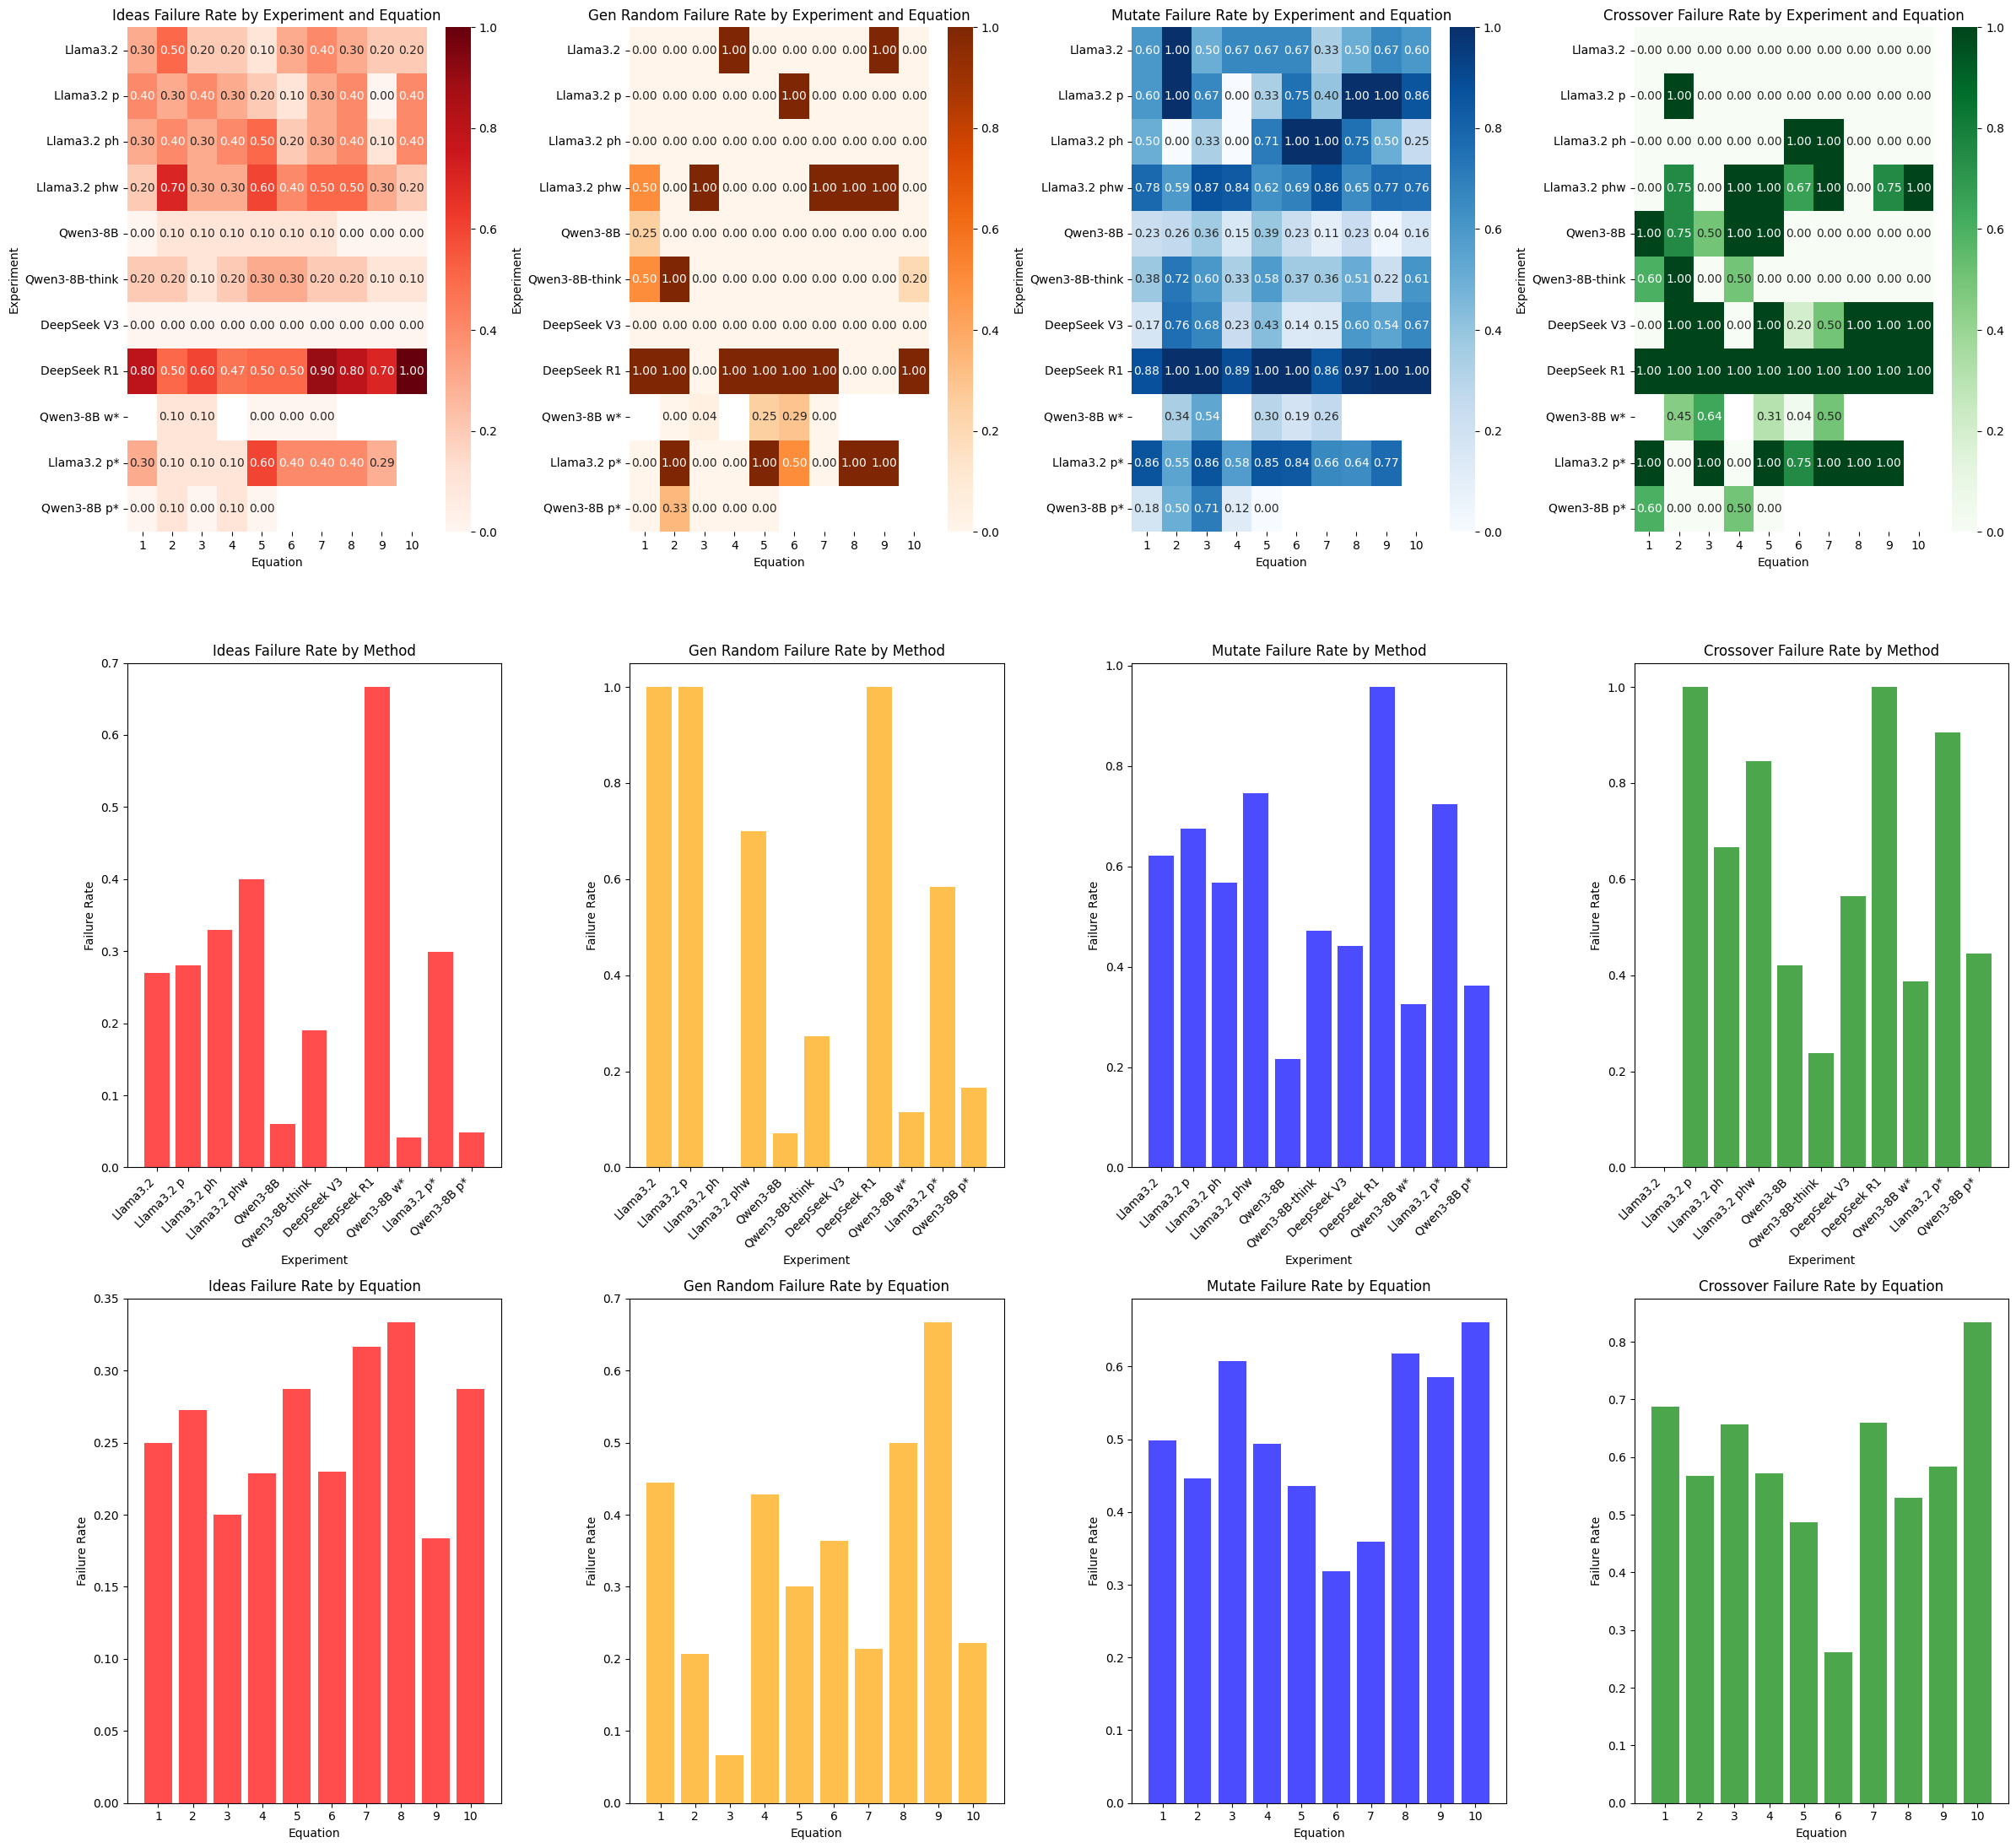


Visualization Summary:
- Processing 11 experiments: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11]
- Experiment labels: ['Llama3.2', 'Llama3.2 p', 'Llama3.2 ph', 'Llama3.2 phw', 'Qwen3-8B', 'Qwen3-8B-think', 'DeepSeek V3', 'DeepSeek R1', 'Qwen3-8B w*', 'Llama3.2 p*', 'Qwen3-8B p*']
- Table dimensions: 11x10 (experiments x equations)


In [48]:
# Create comprehensive visualizations with dynamic experiment count
available_experiments = sorted(df['experiment'].unique())
num_experiments = len(available_experiments)

# Calculate appropriate figure size based on number of experiments
fig_height = max(18, num_experiments * 2)  # Minimum 18, scale with experiments
fig, axes = plt.subplots(3, 4, figsize=(24, fig_height))

# Create experiment labels for current experiments
current_exp_labels = [exp_labels.get(i, f'Exp_{i}') for i in available_experiments]

# Row 1: Heatmaps for each operation type
sns.heatmap(ideas_failure_rate_table, annot=True, fmt='.2f', cmap='Reds', ax=axes[0,0])
axes[0,0].set_title('Ideas Failure Rate by Experiment and Equation')
axes[0,0].set_xlabel('Equation')
axes[0,0].set_ylabel('Experiment')
axes[0,0].set_yticklabels(current_exp_labels, rotation=0)

sns.heatmap(gen_random_failure_rate_table, annot=True, fmt='.2f', cmap='Oranges', ax=axes[0,1])
axes[0,1].set_title('Gen Random Failure Rate by Experiment and Equation')
axes[0,1].set_xlabel('Equation')
axes[0,1].set_ylabel('Experiment')
axes[0,1].set_yticklabels(current_exp_labels, rotation=0)

sns.heatmap(mutate_failure_rate_table, annot=True, fmt='.2f', cmap='Blues', ax=axes[0,2])
axes[0,2].set_title('Mutate Failure Rate by Experiment and Equation')
axes[0,2].set_xlabel('Equation')
axes[0,2].set_ylabel('Experiment')
axes[0,2].set_yticklabels(current_exp_labels, rotation=0)

sns.heatmap(crossover_failure_rate_table, annot=True, fmt='.2f', cmap='Greens', ax=axes[0,3])
axes[0,3].set_title('Crossover Failure Rate by Experiment and Equation')
axes[0,3].set_xlabel('Equation')
axes[0,3].set_ylabel('Experiment')
axes[0,3].set_yticklabels(current_exp_labels, rotation=0)

# Row 2: Bar plots by method for each operation type
method_summary_ideas = df.groupby('experiment').agg({
    'ideas_failed': 'sum',
    'ideas_success': 'sum',
    'ideas_total': 'sum'
}).reset_index()
method_summary_ideas['ideas_failure_rate'] = method_summary_ideas['ideas_failed'] / method_summary_ideas['ideas_total']

method_summary_gen_random = df.groupby('experiment').agg({
    'gen_random_failed': 'sum',
    'gen_random_success': 'sum',
    'gen_random_total': 'sum'
}).reset_index()
method_summary_gen_random['gen_random_failure_rate'] = method_summary_gen_random['gen_random_failed'] / method_summary_gen_random['gen_random_total']

method_summary_mutate = df.groupby('experiment').agg({
    'mutate_failed': 'sum',
    'mutate_success': 'sum',
    'mutate_total': 'sum'
}).reset_index()
method_summary_mutate['mutate_failure_rate'] = method_summary_mutate['mutate_failed'] / method_summary_mutate['mutate_total']

method_summary_crossover = df.groupby('experiment').agg({
    'crossover_failed': 'sum',
    'crossover_success': 'sum',
    'crossover_total': 'sum'
}).reset_index()
method_summary_crossover['crossover_failure_rate'] = method_summary_crossover['crossover_failed'] / method_summary_crossover['crossover_total']

axes[1,0].bar(range(len(method_summary_ideas)), method_summary_ideas['ideas_failure_rate'], color='red', alpha=0.7)
axes[1,0].set_title('Ideas Failure Rate by Method')
axes[1,0].set_xlabel('Experiment')
axes[1,0].set_ylabel('Failure Rate')
axes[1,0].set_xticks(range(len(method_summary_ideas)))
axes[1,0].set_xticklabels(current_exp_labels, rotation=45, ha='right')

axes[1,1].bar(range(len(method_summary_gen_random)), method_summary_gen_random['gen_random_failure_rate'], color='orange', alpha=0.7)
axes[1,1].set_title('Gen Random Failure Rate by Method')
axes[1,1].set_xlabel('Experiment')
axes[1,1].set_ylabel('Failure Rate')
axes[1,1].set_xticks(range(len(method_summary_gen_random)))
axes[1,1].set_xticklabels(current_exp_labels, rotation=45, ha='right')

axes[1,2].bar(range(len(method_summary_mutate)), method_summary_mutate['mutate_failure_rate'], color='blue', alpha=0.7)
axes[1,2].set_title('Mutate Failure Rate by Method')
axes[1,2].set_xlabel('Experiment')
axes[1,2].set_ylabel('Failure Rate')
axes[1,2].set_xticks(range(len(method_summary_mutate)))
axes[1,2].set_xticklabels(current_exp_labels, rotation=45, ha='right')

axes[1,3].bar(range(len(method_summary_crossover)), method_summary_crossover['crossover_failure_rate'], color='green', alpha=0.7)
axes[1,3].set_title('Crossover Failure Rate by Method')
axes[1,3].set_xlabel('Experiment')
axes[1,3].set_ylabel('Failure Rate')
axes[1,3].set_xticks(range(len(method_summary_crossover)))
axes[1,3].set_xticklabels(current_exp_labels, rotation=45, ha='right')

# Row 3: Bar plots by equation for each operation type
equation_summary_ideas = df.groupby('equation').agg({
    'ideas_failed': 'sum',
    'ideas_success': 'sum',
    'ideas_total': 'sum'
}).reset_index()
equation_summary_ideas['ideas_failure_rate'] = equation_summary_ideas['ideas_failed'] / equation_summary_ideas['ideas_total']

equation_summary_gen_random = df.groupby('equation').agg({
    'gen_random_failed': 'sum',
    'gen_random_success': 'sum',
    'gen_random_total': 'sum'
}).reset_index()
equation_summary_gen_random['gen_random_failure_rate'] = equation_summary_gen_random['gen_random_failed'] / equation_summary_gen_random['gen_random_total']

equation_summary_mutate = df.groupby('equation').agg({
    'mutate_failed': 'sum',
    'mutate_success': 'sum',
    'mutate_total': 'sum'
}).reset_index()
equation_summary_mutate['mutate_failure_rate'] = equation_summary_mutate['mutate_failed'] / equation_summary_mutate['mutate_total']

equation_summary_crossover = df.groupby('equation').agg({
    'crossover_failed': 'sum',
    'crossover_success': 'sum',
    'crossover_total': 'sum'
}).reset_index()
equation_summary_crossover['crossover_failure_rate'] = equation_summary_crossover['crossover_failed'] / equation_summary_crossover['crossover_total']

axes[2,0].bar(equation_summary_ideas['equation'], equation_summary_ideas['ideas_failure_rate'], color='red', alpha=0.7)
axes[2,0].set_title('Ideas Failure Rate by Equation')
axes[2,0].set_xlabel('Equation')
axes[2,0].set_ylabel('Failure Rate')
axes[2,0].set_xticks(range(1, 11))

axes[2,1].bar(equation_summary_gen_random['equation'], equation_summary_gen_random['gen_random_failure_rate'], color='orange', alpha=0.7)
axes[2,1].set_title('Gen Random Failure Rate by Equation')
axes[2,1].set_xlabel('Equation')
axes[2,1].set_ylabel('Failure Rate')
axes[2,1].set_xticks(range(1, 11))

axes[2,2].bar(equation_summary_mutate['equation'], equation_summary_mutate['mutate_failure_rate'], color='blue', alpha=0.7)
axes[2,2].set_title('Mutate Failure Rate by Equation')
axes[2,2].set_xlabel('Equation')
axes[2,2].set_ylabel('Failure Rate')
axes[2,2].set_xticks(range(1, 11))

axes[2,3].bar(equation_summary_crossover['equation'], equation_summary_crossover['crossover_failure_rate'], color='green', alpha=0.7)
axes[2,3].set_title('Crossover Failure Rate by Equation')
axes[2,3].set_xlabel('Equation')
axes[2,3].set_ylabel('Failure Rate')
axes[2,3].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

print(f"\nVisualization Summary:")
print(f"- Processing {num_experiments} experiments: {available_experiments}")
print(f"- Experiment labels: {current_exp_labels}")
print(f"- Table dimensions: {num_experiments}x10 (experiments x equations)")

In [49]:
# Comprehensive statistics summary
print("="*80)
print("COMPREHENSIVE LLM CALL FAILURE STATISTICS ANALYSIS")
print("="*80)

# Overall statistics across all operations
total_ideas = df['ideas_total'].sum()
total_gen_random = df['gen_random_total'].sum()
total_mutate = df['mutate_total'].sum()
total_crossover = df['crossover_total'].sum()
total_all_operations = df['total_operations'].sum()

total_ideas_failed = df['ideas_failed'].sum()
total_gen_random_failed = df['gen_random_failed'].sum()
total_mutate_failed = df['mutate_failed'].sum()
total_crossover_failed = df['crossover_failed'].sum()
total_all_failed = df['total_failures'].sum()

print(f"Overall Statistics Across All Experiments and Equations:")
print(f"  Ideas operations: {total_ideas:,} total, {total_ideas_failed:,} failed ({total_ideas_failed/total_ideas:.4f} failure rate)" if total_ideas > 0 else "  Ideas operations: 0 total, 0 failed (N/A failure rate)")
print(f"  Gen Random operations: {total_gen_random:,} total, {total_gen_random_failed:,} failed ({total_gen_random_failed/total_gen_random:.4f} failure rate)" if total_gen_random > 0 else "  Gen Random operations: 0 total, 0 failed (N/A failure rate)")
print(f"  Mutate operations: {total_mutate:,} total, {total_mutate_failed:,} failed ({total_mutate_failed/total_mutate:.4f} failure rate)" if total_mutate > 0 else "  Mutate operations: 0 total, 0 failed (N/A failure rate)")
print(f"  Crossover operations: {total_crossover:,} total, {total_crossover_failed:,} failed ({total_crossover_failed/total_crossover:.4f} failure rate)" if total_crossover > 0 else "  Crossover operations: 0 total, 0 failed (N/A failure rate)")
print(f"  ALL operations: {total_all_operations:,} total, {total_all_failed:,} failed ({total_all_failed/total_all_operations:.4f} failure rate)" if total_all_operations > 0 else "  ALL operations: 0 total, 0 failed (N/A failure rate)")

if total_all_operations > 0:
    print(f"\nOperation Type Breakdown:")
    print(f"  Ideas: {total_ideas/total_all_operations:.1%} of all operations")
    print(f"  Gen Random: {total_gen_random/total_all_operations:.1%} of all operations")
    print(f"  Mutate: {total_mutate/total_all_operations:.1%} of all operations")
    print(f"  Crossover: {total_crossover/total_all_operations:.1%} of all operations")

    print(f"\nFailure Distribution:")
    print(f"  Ideas failures: {total_ideas_failed/total_all_failed:.1%} of all failures" if total_all_failed > 0 else "  Ideas failures: N/A")
    print(f"  Gen Random failures: {total_gen_random_failed/total_all_failed:.1%} of all failures" if total_all_failed > 0 else "  Gen Random failures: N/A")
    print(f"  Mutate failures: {total_mutate_failed/total_all_failed:.1%} of all failures" if total_all_failed > 0 else "  Mutate failures: N/A")
    print(f"  Crossover failures: {total_crossover_failed/total_all_failed:.1%} of all failures" if total_all_failed > 0 else "  Crossover failures: N/A")

# Best and worst performing experiments by operation type
print(f"\n" + "="*80)
print("BEST AND WORST PERFORMING EXPERIMENTS BY OPERATION TYPE")
print("="*80)

for op_type, summary_df, rate_col in [
    ('Ideas', method_summary_ideas, 'ideas_failure_rate'),
    ('Gen Random', method_summary_gen_random, 'gen_random_failure_rate'),
    ('Mutate', method_summary_mutate, 'mutate_failure_rate'),
    ('Crossover', method_summary_crossover, 'crossover_failure_rate'),
    ('Overall', method_summary_overall, 'overall_failure_rate')
]:
    print(f"\n{op_type} Operation:")
    
    # Filter out experiments with zero operations
    valid_summary = summary_df[summary_df[rate_col].notna() & (summary_df[rate_col] >= 0)]
    valid_summary = valid_summary[valid_summary[rate_col.replace('_failure_rate', '_total')] > 0] if rate_col.replace('_failure_rate', '_total') in summary_df.columns else valid_summary
    
    if len(valid_summary) > 0:
        best_idx = valid_summary[rate_col].idxmin()
        worst_idx = valid_summary[rate_col].idxmax()
        
        best_exp = valid_summary.loc[best_idx, 'experiment']
        worst_exp = valid_summary.loc[worst_idx, 'experiment']
        best_rate = valid_summary.loc[best_idx, rate_col]
        worst_rate = valid_summary.loc[worst_idx, rate_col]
        
        print(f"  Best: {exp_labels[best_exp]} (failure rate: {best_rate:.4f})")
        print(f"  Worst: {exp_labels[worst_exp]} (failure rate: {worst_rate:.4f})")
        print(f"  Ratio (worst/best): {worst_rate/best_rate:.2f}x" if best_rate > 0 else "  Ratio: N/A (best has 0 failures)")
    else:
        print("  No valid data for this operation type")

# Most problematic equations
print(f"\n" + "="*80)
print("MOST PROBLEMATIC EQUATIONS BY OPERATION TYPE")
print("="*80)

for op_type, summary_df, rate_col in [
    ('Ideas', equation_summary_ideas, 'ideas_failure_rate'),
    ('Gen Random', equation_summary_gen_random, 'gen_random_failure_rate'),
    ('Mutate', equation_summary_mutate, 'mutate_failure_rate'),
    ('Crossover', equation_summary_crossover, 'crossover_failure_rate'),
    ('Overall', equation_summary_overall, 'overall_failure_rate')
]:
    print(f"\n{op_type} Operation:")
    
    # Filter out equations with zero operations
    valid_summary = summary_df[summary_df[rate_col].notna() & (summary_df[rate_col] >= 0)]
    valid_summary = valid_summary[valid_summary[rate_col.replace('_failure_rate', '_total')] > 0] if rate_col.replace('_failure_rate', '_total') in summary_df.columns else valid_summary
    
    if len(valid_summary) > 0:
        # Sort by failure rate (worst first)
        sorted_summary = valid_summary.sort_values(rate_col, ascending=False)
        
        print(f"  Top 3 most problematic equations:")
        for i, (_, row) in enumerate(sorted_summary.head(3).iterrows()):
            eq_num = int(row['equation'])
            rate = row[rate_col]
            print(f"    {i+1}. Equation {eq_num}: {rate:.4f} failure rate")
        
        print(f"  Top 3 best performing equations:")
        for i, (_, row) in enumerate(sorted_summary.tail(3).iterrows()):
            eq_num = int(row['equation'])
            rate = row[rate_col]
            print(f"    {i+1}. Equation {eq_num}: {rate:.4f} failure rate")
    else:
        print("  No valid data for this operation type")

print("\n" + "="*80)
print("OPERATION COUNTING METHODOLOGY")
print("="*80)
print("这个分析使用了智能的操作分组方法论：")
print()
print("1. 操作识别:")
print("   - 成功操作: [operation] content")  
print("   - 失败操作: [operation|failed] content")
print()
print("2. 配对逻辑（适配不同操作类型）:")
print("   - mutate/crossover: 更可能出现连续配对（重试机制），搜索范围20行")
print("   - ideas/gen_random: 通常单次操作，搜索范围10行")
print("   - 如果发现连续的同类型操作，组成一对")
print()
print("3. 失败判定:")
print("   - 配对操作: 任一操作失败 → 整对失败")
print("   - 单独操作: 根据自身状态判定")
print()
print("4. 计数规则:")
print("   - 配对算作1个操作单元（不是2个）")
print("   - 单次操作算作1个操作单元")
print("   - 成功: 组内所有操作都成功")
print("   - 失败: 组内至少一个操作失败")
print()
print("5. 操作类型特点:")
print("   - Ideas: 从表达式中提取概念/假设，通常单次")
print("   - Gen Random: 生成随机表达式，通常单次")  
print("   - Mutate: 变异表达式，可能有重试，出现配对")
print("   - Crossover: 交叉操作，可能有重试，出现配对")
print()
print("这确保了统计的准确性，特别是针对不同操作类型的出现模式。")

print("="*80)

COMPREHENSIVE LLM CALL FAILURE STATISTICS ANALYSIS
Overall Statistics Across All Experiments and Equations:
  Ideas operations: 981 total, 253 failed (0.2579 failure rate)
  Gen Random operations: 154 total, 42 failed (0.2727 failure rate)
  Mutate operations: 3,848 total, 1,829 failed (0.4753 failure rate)
  Crossover operations: 264 total, 143 failed (0.5417 failure rate)
  ALL operations: 5,247 total, 2,267 failed (0.4321 failure rate)

Operation Type Breakdown:
  Ideas: 18.7% of all operations
  Gen Random: 2.9% of all operations
  Mutate: 73.3% of all operations
  Crossover: 5.0% of all operations

Failure Distribution:
  Ideas failures: 11.2% of all failures
  Gen Random failures: 1.9% of all failures
  Mutate failures: 80.7% of all failures
  Crossover failures: 6.3% of all failures

BEST AND WORST PERFORMING EXPERIMENTS BY OPERATION TYPE

Ideas Operation:
  Best: DeepSeek V3 (failure rate: 0.0000)
  Worst: DeepSeek R1 (failure rate: 0.6667)
  Ratio: N/A (best has 0 failures)

G

In [50]:
# Comprehensive statistics summary for all available experiments
available_experiments = sorted(df['experiment'].unique())

print("="*80)
print("COMPREHENSIVE LLM CALL FAILURE STATISTICS ANALYSIS")
print("="*80)
print(f"Experiments analyzed: {available_experiments}")
print(f"Total experiments: {len(available_experiments)}")

# Overall statistics across all operations
total_ideas = df['ideas_total'].sum()
total_gen_random = df['gen_random_total'].sum()
total_mutate = df['mutate_total'].sum()
total_crossover = df['crossover_total'].sum()
total_all_operations = df['total_operations'].sum()

total_ideas_failed = df['ideas_failed'].sum()
total_gen_random_failed = df['gen_random_failed'].sum()
total_mutate_failed = df['mutate_failed'].sum()
total_crossover_failed = df['crossover_failed'].sum()
total_all_failed = df['total_failures'].sum()

print(f"\nOverall Statistics Across All {len(available_experiments)} Experiments and Equations:")
print(f"  Ideas operations: {total_ideas:,} total, {total_ideas_failed:,} failed ({total_ideas_failed/total_ideas:.4f} failure rate)")
print(f"  Gen Random operations: {total_gen_random:,} total, {total_gen_random_failed:,} failed ({total_gen_random_failed/total_gen_random:.4f} failure rate)" if total_gen_random > 0 else "  Gen Random operations: 0 total, 0 failed (N/A failure rate)")
print(f"  Mutate operations: {total_mutate:,} total, {total_mutate_failed:,} failed ({total_mutate_failed/total_mutate:.4f} failure rate)")
print(f"  Crossover operations: {total_crossover:,} total, {total_crossover_failed:,} failed ({total_crossover_failed/total_crossover:.4f} failure rate)" if total_crossover > 0 else "  Crossover operations: 0 total, 0 failed (N/A failure rate)")
print(f"  ALL operations: {total_all_operations:,} total, {total_all_failed:,} failed ({total_all_failed/total_all_operations:.4f} failure rate)")

print(f"\nOperation Type Breakdown:")
print(f"  Ideas: {total_ideas/total_all_operations:.1%} of all operations")
print(f"  Gen Random: {total_gen_random/total_all_operations:.1%} of all operations")
print(f"  Mutate: {total_mutate/total_all_operations:.1%} of all operations")
print(f"  Crossover: {total_crossover/total_all_operations:.1%} of all operations")

print(f"\nFailure Distribution:")
print(f"  Ideas failures: {total_ideas_failed/total_all_failed:.1%} of all failures")
print(f"  Gen Random failures: {total_gen_random_failed/total_all_failed:.1%} of all failures")
print(f"  Mutate failures: {total_mutate_failed/total_all_failed:.1%} of all failures")
print(f"  Crossover failures: {total_crossover_failed/total_all_failed:.1%} of all failures")

# Best and worst performing experiments by operation type
print(f"\n" + "="*80)
print("BEST AND WORST PERFORMING EXPERIMENTS BY OPERATION TYPE")
print("="*80)

for op_type, summary_df, rate_col in [
    ('Ideas', method_summary_ideas, 'ideas_failure_rate'),
    ('Gen Random', method_summary_gen_random, 'gen_random_failure_rate'),
    ('Mutate', method_summary_mutate, 'mutate_failure_rate'),
    ('Crossover', method_summary_crossover, 'crossover_failure_rate')
]:
    print(f"\n{op_type} Operation:")
    
    # Filter out experiments with zero operations
    valid_summary = summary_df[summary_df[rate_col].notna() & (summary_df[rate_col] >= 0)]
    
    if len(valid_summary) > 0:
        best_idx = valid_summary[rate_col].idxmin()
        worst_idx = valid_summary[rate_col].idxmax()
        
        best_exp = valid_summary.loc[best_idx, 'experiment']
        worst_exp = valid_summary.loc[worst_idx, 'experiment']
        best_rate = valid_summary.loc[best_idx, rate_col]
        worst_rate = valid_summary.loc[worst_idx, rate_col]
        
        best_label = exp_labels.get(best_exp, f'Exp_{best_exp}')
        worst_label = exp_labels.get(worst_exp, f'Exp_{worst_exp}')
        
        print(f"  Best: {best_label} (exp_{best_exp}) - failure rate: {best_rate:.4f}")
        print(f"  Worst: {worst_label} (exp_{worst_exp}) - failure rate: {worst_rate:.4f}")
        print(f"  Ratio (worst/best): {worst_rate/best_rate:.2f}x" if best_rate > 0 else "  Ratio: N/A (best has 0 failures)")
    else:
        print("  No valid data for this operation type")

# Most problematic equations
print(f"\n" + "="*80)
print("MOST PROBLEMATIC EQUATIONS BY OPERATION TYPE")
print("="*80)

for op_type, summary_df, rate_col in [
    ('Ideas', equation_summary_ideas, 'ideas_failure_rate'),
    ('Gen Random', equation_summary_gen_random, 'gen_random_failure_rate'),
    ('Mutate', equation_summary_mutate, 'mutate_failure_rate'),
    ('Crossover', equation_summary_crossover, 'crossover_failure_rate')
]:
    print(f"\n{op_type} Operation:")
    
    # Filter out equations with zero operations
    valid_summary = summary_df[summary_df[rate_col].notna() & (summary_df[rate_col] >= 0)]
    
    if len(valid_summary) > 0:
        # Sort by failure rate (worst first)
        sorted_summary = valid_summary.sort_values(rate_col, ascending=False)
        
        print(f"  Top 3 most problematic equations:")
        for i, (_, row) in enumerate(sorted_summary.head(3).iterrows()):
            eq_num = int(row['equation'])
            rate = row[rate_col]
            print(f"    {i+1}. Equation {eq_num}: {rate:.4f} failure rate")
        
        print(f"  Top 3 best performing equations:")
        for i, (_, row) in enumerate(sorted_summary.tail(3).iterrows()):
            eq_num = int(row['equation'])
            rate = row[rate_col]
            print(f"    {i+1}. Equation {eq_num}: {rate:.4f} failure rate")
    else:
        print("  No valid data for this operation type")

# Operation correlation analysis
print(f"\n" + "="*80)
print("OPERATION TYPE CORRELATION ANALYSIS")
print("="*80)

correlation_columns = ['ideas_failure_rate', 'mutate_failure_rate', 'overall_failure_rate']
if total_gen_random > 0:
    correlation_columns.insert(1, 'gen_random_failure_rate')
if total_crossover > 0:
    correlation_columns.insert(-1, 'crossover_failure_rate')

correlation_df = df[correlation_columns].corr()
print("Failure Rate Correlations:")
print(correlation_df.round(4))

print(f"\nKey Insights:")
print(f"  - Ideas-Mutate correlation: {correlation_df.loc['ideas_failure_rate', 'mutate_failure_rate']:.3f}")
if total_gen_random > 0:
    print(f"  - Gen Random-Mutate correlation: {correlation_df.loc['gen_random_failure_rate', 'mutate_failure_rate']:.3f}")
if total_crossover > 0:
    print(f"  - Crossover-Mutate correlation: {correlation_df.loc['crossover_failure_rate', 'mutate_failure_rate']:.3f}")

# Experiment coverage summary
print(f"\n" + "="*80)
print("EXPERIMENT COVERAGE SUMMARY")
print("="*80)

exp_coverage = df['experiment'].value_counts().sort_index()
print(f"Data coverage across {len(available_experiments)} experiments:")
for exp_num in available_experiments:
    count = exp_coverage.get(exp_num, 0)
    label = exp_labels.get(exp_num, f'Exp_{exp_num}')
    print(f"  exp_{exp_num} ({label}): {count} equations")

missing_experiments = []
for i in range(max(available_experiments) + 1):
    if i not in available_experiments:
        missing_experiments.append(i)

if missing_experiments:
    print(f"\nMissing experiments: {missing_experiments}")
    for exp_num in missing_experiments:
        label = exp_labels.get(exp_num, f'Exp_{exp_num}')
        print(f"  exp_{exp_num} ({label}): No data available")

print("\n" + "="*80)
print("OPERATION COUNTING METHODOLOGY")
print("="*80)
print("This analysis uses a sophisticated operation grouping methodology:")
print()
print("1. DYNAMIC EXPERIMENT DETECTION:")
print("   - Auto-detects all available exp_N directories")
print("   - Only processes experiments with actual llm_calls.txt data")
print("   - Handles missing experiments gracefully (e.g., exp_8)")
print()
print("2. CONSECUTIVE OPERATION PAIRING:")
print("   - mutate/crossover: Higher retry frequency (20-line gap tolerance)")
print("   - ideas/gen_random: Lower retry frequency (10-line gap tolerance)")
print("   - Pairs count as 1 operation unit, failure propagates within pairs")
print()
print("3. SCALABLE ANALYSIS:")
print(f"   - Processes {len(available_experiments)} experiments dynamically")
print(f"   - Creates {len(available_experiments)}x10 tables (experiments x equations)")
print("   - Adapts visualizations to any number of experiments")
print()
print("4. COMPREHENSIVE STATISTICS:")
print("   - Operation-specific failure patterns")
print("   - Cross-experiment performance comparison")  
print("   - Equation-level difficulty assessment")
print("   - Correlation analysis between operation types")

print("="*80)

COMPREHENSIVE LLM CALL FAILURE STATISTICS ANALYSIS
Experiments analyzed: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11]
Total experiments: 11

Overall Statistics Across All 11 Experiments and Equations:
  Ideas operations: 981 total, 253 failed (0.2579 failure rate)
  Gen Random operations: 154 total, 42 failed (0.2727 failure rate)
  Mutate operations: 3,848 total, 1,829 failed (0.4753 failure rate)
  Crossover operations: 264 total, 143 failed (0.5417 failure rate)
  ALL operations: 5,247 total, 2,267 failed (0.4321 failure rate)

Operation Type Breakdown:
  Ideas: 18.7% of all operations
  Gen Random: 2.9% of all operations
  Mutate: 73.3% of all operations
  Crossover: 5.0% of all operations

Failure Distribution:
  Ideas failures: 11.2% of all failures
  Gen Random failures: 1.9% of all failures
  Mutate failures: 80.7% of all failures
  Crossover failures: 6.3% of all failures

BEST AND WORST PERFORMING EXPERIMENTS BY OPERATION TYPE

Ideas Operation:
  Best: DeepSeek V3 (exp_6) - failure ra

In [51]:
# Run the complete updated analysis with dynamic experiment detection
print("🚀 RUNNING EXPANDED LLM FAILURE ANALYSIS")
print("="*60)
print("This analysis will:")
print("✓ Auto-detect ALL available exp_N directories")
print("✓ Handle missing experiments (like exp_8)")
print("✓ Create dynamic NxM tables (N=experiments, M=10 equations)")  
print("✓ Generate scalable visualizations")
print("✓ Provide comprehensive statistics")
print("="*60)

# Auto-detect available experiments
base_path = "lasr_runs_synthetic_llama32/"
available_experiments = detect_available_experiments(base_path)

if available_experiments:
    print(f"\n✅ Found {len(available_experiments)} experiments with data: {available_experiments}")
    
    # Show what we're analyzing
    current_labels = [exp_labels.get(i, f'Exp_{i}') for i in available_experiments]
    print(f"📊 Analysis will include: {', '.join(current_labels)}")
    
    # Run the scan
    print(f"\n🔍 Scanning experiment data...")
    df = scan_lasr_runs(base_path, available_experiments)
    
    if len(df) > 0:
        num_combinations = len(df)
        num_experiments = len(available_experiments)
        print(f"\n✅ Successfully collected data:")
        print(f"   - {num_experiments} experiments") 
        print(f"   - {num_combinations} experiment-equation combinations")
        print(f"   - Table size: {num_experiments}x10")
        
        # Show quick summary
        total_ops = df['total_operations'].sum()
        total_fails = df['total_failures'].sum()
        overall_rate = total_fails / total_ops if total_ops > 0 else 0
        
        print(f"\n📈 Quick Summary:")
        print(f"   - Total operations: {total_ops:,}")
        print(f"   - Total failures: {total_fails:,}")
        print(f"   - Overall failure rate: {overall_rate:.1%}")
        
        print(f"\n🎯 Ready for detailed analysis!")
        print(f"   - Run visualization cells to see {num_experiments}x10 heatmaps")
        print(f"   - Check statistics for cross-experiment comparisons")
        print(f"   - All {len(available_experiments)} experiments will be included")
        
    else:
        print("❌ No data was collected. Check file paths and formats.")
        
else:
    print("❌ No experiments with data found. Check the base directory path.")

🚀 RUNNING EXPANDED LLM FAILURE ANALYSIS
This analysis will:
✓ Auto-detect ALL available exp_N directories
✓ Handle missing experiments (like exp_8)
✓ Create dynamic NxM tables (N=experiments, M=10 equations)
✓ Generate scalable visualizations
✓ Provide comprehensive statistics
✓ Found experiment 0 with data (10 equations)
✓ Found experiment 1 with data (10 equations)
✓ Found experiment 10 with data (9 equations)
✓ Found experiment 11 with data (5 equations)
✓ Found experiment 2 with data (10 equations)
✓ Found experiment 3 with data (10 equations)
✓ Found experiment 4 with data (10 equations)
✓ Found experiment 5 with data (10 equations)
✓ Found experiment 6 with data (10 equations)
✓ Found experiment 7 with data (10 equations)
✓ Found experiment 9 with data (5 equations)

✅ Found 11 experiments with data: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11]
📊 Analysis will include: Llama3.2, Llama3.2 p, Llama3.2 ph, Llama3.2 phw, Qwen3-8B, Qwen3-8B-think, DeepSeek V3, DeepSeek R1, Qwen3-8B w*, Llama3.